In order to use the function to create plots you will need to put format inputs correctly as I am not a great programmer. 

>Every input has to be a string, ie: "your_input_here"

>Make sure you place your data file in the folder where this code is stored, I won't upload the data files as they're quite large for github 

>The valid input for "data" are as follows 

date:  -  Date and Time (utc) \
ind:   -  irainfall   Rainfall indicator \
rain:  -  Precipitation Amount (mm)   \
ind:   -  ittt Dry bulb indicator \
temp:  -  Air Temperature (C) \
ind:   -  iwb Wet bulb indicator \
wetb:  -  Wet Bulb Temperature (C) \
dewpt: -  Dew Point Temperature (C)     \         
rhum:  -  Relative Humidity (%) \
vappr: -  Vapour Pressure (hPa)  \
msl:   -  Mean Sea Level Pressure (hPa) \
ind:   -  itabspeed wind Speed indicator \
wdsp:  -  Mean Wind Speed (knot) \
ind:   -  itabdir  wind dir indicator \
wddir: -  Predominant Wind Direction (degree) \
ww:    -  Synop code for Present Weather \
w:     -  Synop code for Past Weather \
sun:   -  Sunshine duration (hours) \
vis:   -  Visibility (m) \
clht:  -  Cloud height (100's of ft) - 999 if none  \
clamt: -  Cloud amount \

And not all stations have all of these!

>>Have fun!

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import csv
import pandas as pd

In [ ]:
def pull_data(file, data): 
    ### takes a csv file from met eireann as an input and outputs an array of [dates,data] where data is specified in markdown above
    skip_lines = 0
    with open(file, "r") as f:
        for line in f:
            if line.strip().lower().startswith("date,"): #strips lines of blank spaces, ignores case and searches for date,
                break
            skip_lines += 1

    df = pd.read_csv(file, skiprows=skip_lines) #reads out data and skips irrelevant lines

    df.columns = df.columns.str.strip()

    df["date"] = pd.to_datetime(df["date"], format="%d-%b-%Y %H:%M")#converts dates into useable format
    result = df[["date", str(data)]].to_numpy()# returns numpy array
    return result

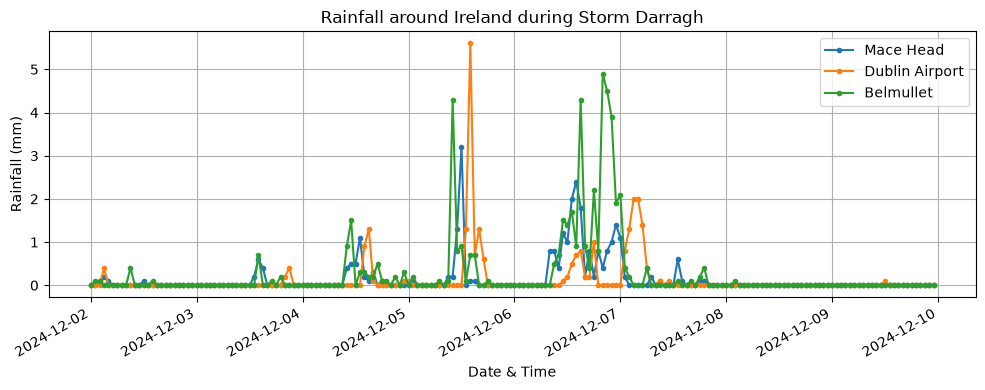

In [14]:
#run function on three places (ive included belmullet because it set rainfall record for storm darragh)
maceraindata_storm = pull_data("mace_head_data_storm.csv","rain")
dubraindata_storm = pull_data("dubairport_data_storm.csv","rain")
belmulletraindata_storm = pull_data("belmullet_data_storm.csv","rain")

#pulls and fixes date format
macedates = pd.to_datetime(maceraindata_storm[:, 0], format="%d-%b-%Y %H:%M")
dubdates = pd.to_datetime(dubraindata_storm[:, 0], format="%d-%b-%Y %H:%M")
beldates = pd.to_datetime(belmulletraindata_storm[:, 0], format="%d-%b-%Y %H:%M")

#pulls out rain data
macerain = maceraindata_storm[:, 1]
dubrain = dubraindata_storm[:, 1]
belrain = belmulletraindata_storm[:, 1]

#plots
plt.figure(figsize=(10, 4))
plt.plot(macedates, macerain, marker=".", linestyle="-",label="Mace Head")
plt.plot(dubdates, dubrain, marker=".", linestyle="-",label="Dublin Airport")
plt.plot(beldates, belrain, marker=".", linestyle="-",label="Belmullet")

plt.gcf().autofmt_xdate()  # Rotates date labels 

plt.title("Rainfall around Ireland during Storm Darragh")
plt.xlabel("Date & Time")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.tight_layout()
plt.legend()

plt.show()

/tmp/ipykernel_358506/1226566741.py:11: DtypeWarning: Columns (8: vappr, 9: rhum, 14: wddir, 18: vis) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file, skiprows=skip_lines)


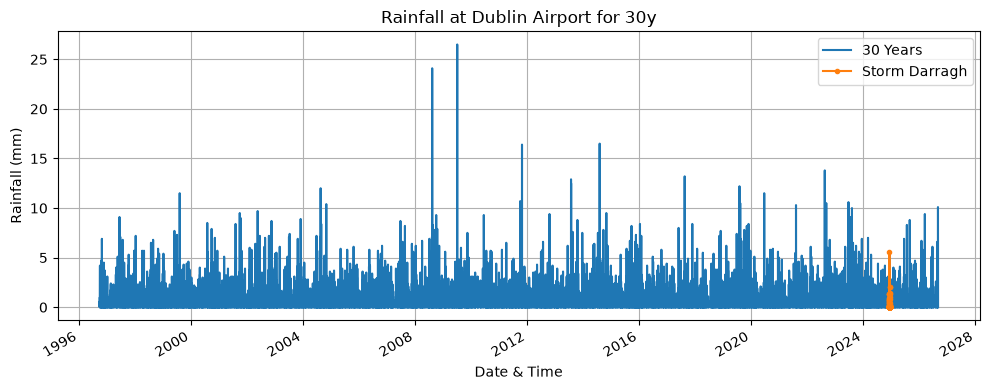

In [20]:
dubraindata_30y = pull_data("dubairport_data_30y.csv","rain")

dubdates_30 = pd.to_datetime(dubraindata_30y[:, 0], format="%d-%b-%Y %H:%M")
dubrain_30 = dubraindata_30y[:, 1]
plt.figure(figsize=(10, 4))
plt.plot(dubdates_30, dubrain_30, marker=" ", linestyle="-",label="30 Years")
plt.plot(dubdates, dubrain, marker=".", linestyle="-",label="Storm Darragh")
plt.gcf().autofmt_xdate()  # Rotates date labels 
plt.title("Rainfall at Dublin Airport for 30y")
plt.xlabel("Date & Time")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.tight_layout()
plt.legend()

plt.show()